# Detección de temas

> Cómo descubrir de qué hablan miles de documentos sin etiquetarlos: modelos de temas con LDA (gensim), elección del número de temas con la coherencia, distribución de temas por documento, y cómo interpretar y etiquetar los temas con recursos léxicos (WordNet y ConceptNet), sobre reseñas de Yelp. Comparamos también la similitud de WordNet con la de los embeddings. Con los errores típicos: incluir adjetivos de opinión, fiarse de una sola ejecución, tomar el primer sentido de WordNet y comparar escalas de similitud distintas.
>
> **Requisitos previos:** [Representación vectorial y TF-IDF](03-representacion-vectorial-tfidf.ipynb) · [Embeddings de palabras](04-embeddings-de-palabras.ipynb) · **Relacionado:** [Clasificación de texto](06-clasificacion-de-texto.ipynb) · [K-means](../04-machine-learning/05-kmeans-y-derivados.ipynb)

## 1. Idea clave

Un **modelo de temas** (*topic model*) resume una colección de documentos en unos pocos **temas**, cada uno descrito por las palabras que más usa (*room*, *hotel*, *bed*, *staff* → «hoteles»), y describe cada documento como una **mezcla** de temas (una reseña puede ser un 70 % comida y un 30 % servicio). Es aprendizaje no supervisado: no necesita etiquetas, así que sirve para explorar un corpus, organizar documentos o crear variables para un modelo posterior.

El modelo clásico es **LDA** (*latent Dirichlet allocation*). Lo difícil no es entrenarlo, sino decidir **cuántos temas** pedir y **qué significa** cada uno: los temas son listas de palabras que hay que interpretar. Para lo primero se usan medidas de **coherencia**; para lo segundo ayudan los recursos léxicos como **WordNet** (jerarquía de conceptos hecha a mano) y **ConceptNet** (red de conocimiento de sentido común), que también sirven para medir la similitud entre palabras de forma distinta a los [embeddings](04-embeddings-de-palabras.ipynb).

## 2. Conceptos importantes

### 2.1. LDA

LDA (Blei, Ng y Jordan, 2003) supone que cada documento se generó así:

1. Para cada tema $k = 1, \dots, K$, una distribución sobre el vocabulario $\boldsymbol{\varphi}_k \sim \operatorname{Dirichlet}(\eta)$: qué palabras usa el tema.
2. Para cada documento $d$, una mezcla de temas $\boldsymbol{\theta}_d \sim \operatorname{Dirichlet}(\alpha)$.
3. Para cada palabra del documento, se elige un tema $z \sim \operatorname{Categórica}(\boldsymbol{\theta}_d)$ y después la palabra $w \sim \operatorname{Categórica}(\boldsymbol{\varphi}_z)$.

Solo se observan las palabras ($w$); el entrenamiento invierte el proceso para estimar $\boldsymbol{\varphi}_k$ y $\boldsymbol{\theta}_d$ (gensim usa inferencia variacional). La distribución de Dirichlet genera vectores de proporciones que suman 1; sus parámetros controlan cuánto se concentran: un $\alpha$ pequeño da documentos con pocos temas, y un $\eta$ pequeño, temas con pocas palabras dominantes. Con `alpha="auto"` y `eta="auto"`, gensim los aprende de los datos.

LDA trabaja con la [bolsa de palabras](03-representacion-vectorial-tfidf.ipynb) (recuentos, no TF-IDF): el orden se pierde y lo que importa es qué palabras coinciden en los mismos documentos. Por eso el preprocesamiento decide mucho: normalmente se lematiza y se dejan solo los **nombres**, que son los que describen de qué se habla.

### 2.2. Coherencia: cuántos temas

La **perplejidad** (lo bien que el modelo predice documentos no vistos) se correlaciona mal con lo que una persona considera un tema bueno. Las medidas de **coherencia** puntúan cada tema por lo mucho que sus palabras principales aparecen juntas en el corpus. La más usada, $C_V$ (Röder et al., 2015), combina la [información mutua puntual normalizada](02-n-gramas-y-colocaciones.ipynb) entre las palabras principales, calculada con una ventana deslizante, y la similitud del coseno entre esos vectores; va de 0 a 1 y más es mejor. Se entrena el modelo con varios $K$ y se elige uno con coherencia alta y temas interpretables, no necesariamente el máximo.

### 2.3. WordNet

**WordNet** es una base de datos léxica del inglés hecha por lingüistas en Princeton. Agrupa las palabras en **synsets** (conjuntos de sinónimos que expresan un sentido: `server.n.02` es el camarero, `server.n.03` el ordenador) unidos por relaciones: **hiperonimia** (*pizza* es un tipo de *dish*, que es un tipo de *nutriment*… hasta *entity*), meronimia (parte de), antonimia. Con esa jerarquía se definen similitudes entre sentidos:

- **Camino** (*path*): $1 / (1 + \text{longitud del camino más corto entre los dos synsets})$.
- **Wu-Palmer**: $2\cdot\operatorname{prof}(\text{ancestro común}) / (\operatorname{prof}(s_1) + \operatorname{prof}(s_2))$, donde $\operatorname{prof}$ es la profundidad en la jerarquía y el ancestro común es el más profundo que comparten (*lowest common hypernym*). Entre 0 y 1.
- **Leacock-Chodorow**: $-\log\big(\text{longitud del camino} / (2\cdot\text{profundidad máxima})\big)$; no está acotada.

El ancestro común también sirve para **etiquetar** un grupo de palabras: el de *pizza* y *hamburger* es *dish*. Como las palabras tienen varios sentidos, para comparar dos palabras (no dos sentidos) se suele tomar el **mejor par de sentidos**: la máxima similitud entre todos los sentidos de una y de otra.

### 2.4. ConceptNet

**ConceptNet** (Speer, Chin y Havasi, 2017) es un grafo de conocimiento de sentido común construido con contribuciones colectivas, Wikcionario, WordNet y otras fuentes. Sus aristas son relaciones como `IsA` (*pizza* es *fast food*), `AtLocation` (*pizza* en un *oven* o un *restaurant*), `UsedFor`, `PartOf` o `RelatedTo`. Cubre muchas más palabras y relaciones que WordNet (incluidas las temáticas), pero es más ruidoso.

### 2.5. Similitud taxonómica frente a distribucional

WordNet mide **similitud taxonómica**: si dos conceptos están cerca en la jerarquía «es un tipo de». Los [embeddings](04-embeddings-de-palabras.ipynb) miden **similitud distribucional**: si dos palabras se usan en los mismos contextos, sean hermanos (*pizza*, *burger*), antónimos (*good*, *bad*) o temas relacionados (*pizza*, *oven*). Son dos preguntas distintas, y sus valores no están en la misma escala.

## 3. Código

Usamos el mismo corpus que en [preprocesamiento de texto](01-preprocesamiento-de-texto.ipynb): reseñas de prueba de **Yelp Review Full** (Zhang, Zhao y LeCun, 2015), en inglés, de negocios de todo tipo (restaurantes, hoteles, peluquerías, tiendas…), descargadas de Hugging Face y guardadas en `data/`. Para que el etiquetado con spaCy no se alargue, trabajamos con una muestra de 20 000 reseñas.

Como recursos léxicos usamos WordNet (incluido en NLTK) y un volcado de las relaciones en inglés de **ConceptNet 5** publicado en Hugging Face (unos 30 MB, se descarga una vez en `data/`), porque la API pública de ConceptNet no siempre está disponible. Para comparar similitudes, los vectores GloVe del [notebook de embeddings](04-embeddings-de-palabras.ipynb).

In [1]:
import contextlib
import html
import io
import itertools
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import spacy
warnings.filterwarnings("ignore", message="IProgress not found")    # aviso de tqdm al importar datasets
from datasets import load_dataset
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel, KeyedVectors, LdaModel
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import logging as hf_logging
from nltk.corpus import wordnet as wn

hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore", message="NLTK will not authorize")   # aviso de permisos del directorio de NLTK
nltk.download("wordnet", quiet=True);

In [2]:
with contextlib.redirect_stderr(io.StringIO()):          # silencia las barras de descarga
    yelp = load_dataset(
        "Yelp/yelp_review_full",
        data_files={"test": "yelp_review_full/test-00000-of-00001.parquet"},   # solo el conjunto de prueba
        split="test",
        cache_dir="data",
        verification_mode="no_checks",                     # no exige descargar también el de entrenamiento
    )

reviews = yelp.to_pandas().sample(20_000, random_state=42).reset_index(drop=True)
reviews["stars"] = reviews["label"] + 1
print(reviews.shape)
print(reviews["stars"].value_counts().sort_index().to_dict())

(20000, 3)
{1: 3944, 2: 4046, 3: 4026, 4: 4013, 5: 3971}


### 3.1. Preparación: lemas de los nombres

Limpiamos como en [preprocesamiento de texto](01-preprocesamiento-de-texto.ipynb), etiquetamos con spaCy (en 4 procesos, para ir más rápido) y nos quedamos con los lemas de los **nombres** que no son palabras vacías. Guardamos también una versión con nombres y adjetivos para compararlas en la sección 4.

In [3]:
def clean(text):
    text = text.replace("\\n", " ").replace('\\"', '"')    # secuencias escapadas
    text = html.unescape(text)                              # &amp; -> &
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)      # URL
    return re.sub(r"\s+", " ", text).strip()

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])   # etiquetador y lematizador
nouns, nouns_adjs = [], []
for doc in nlp.pipe(reviews["text"].map(clean), batch_size=500, n_process=4):
    words = [t for t in doc if t.is_alpha and not t.is_stop]
    nouns.append([t.lemma_.lower() for t in words if t.pos_ == "NOUN"])
    nouns_adjs.append([t.lemma_.lower() for t in words if t.pos_ in ("NOUN", "ADJ")])

print(f"Nombres por reseña (media): {np.mean([len(n) for n in nouns]):.1f}")
print(nouns[0][:20])

Nombres por reseña (media): 24.8
['day', 'lease', 'size', 'time', 'store', 'eye', 'lash', 'one', 'help', 'replacement', 'cat', 'weight', 'size', 'attempt', 'dog', 'size', 'cat', 'store', 'section', 'pet']


LDA de gensim necesita un diccionario (palabra ↔ índice) y cada documento como lista de pares `(índice, recuento)`. Con `filter_extremes` quitamos los nombres que aparecen en menos de 20 reseñas (no pueden definir un tema) y los que aparecen en más de la mitad (no distinguen ninguno).

In [4]:
dictionary = Dictionary(nouns)
dictionary.filter_extremes(no_below=20, no_above=0.5)
corpus = [dictionary.doc2bow(doc) for doc in nouns]
print(f"Vocabulario: {len(dictionary):,} nombres · documento 0: {corpus[0][:8]}")

Vocabulario: 2,115 nombres · documento 0: [(0, 1), (1, 2), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1)]


### 3.2. Cuántos temas: coherencia $C_V$

Entrenamos LDA con distintos números de temas (5 pasadas por el corpus, $\alpha$ y $\eta$ aprendidos) y calculamos la coherencia $C_V$ de cada modelo. Como el resultado depende de la inicialización aleatoria, repetimos cada $K$ con tres semillas.

In [5]:
def train_lda(corpus, dictionary, k, seed):
    return LdaModel(corpus, id2word=dictionary, num_topics=k, passes=5,
                    alpha="auto", eta="auto", random_state=seed)

def coherence(model, texts, dictionary):
    return CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence="c_v").get_coherence()

ks, seeds = [4, 6, 8, 12], [42, 7, 123]
models, scores = {}, {}
for k in ks:
    for seed in seeds:
        models[k, seed] = train_lda(corpus, dictionary, k, seed)
        scores[k, seed] = coherence(models[k, seed], nouns, dictionary)

cv = pd.Series(scores).unstack()                           # filas: K, columnas: semilla
cv.columns = [f"semilla {s}" for s in cv.columns]
cv["media"], cv["desv. típica"] = cv.mean(axis=1), cv.std(axis=1)
cv.round(3)

,semilla 7,semilla 42,semilla 123,media,desv. típica
4,0.552,0.552,0.590,0.565,0.022
6,0.604,0.608,0.575,0.596,0.018
8,0.584,0.607,0.611,0.601,0.014
12,0.564,0.586,0.601,0.584,0.019


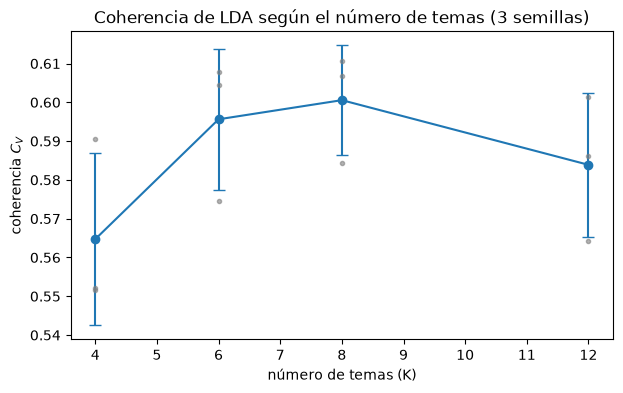

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(cv.index, cv["media"], yerr=cv["desv. típica"], marker="o", capsize=4)
for seed in seeds:
    ax.plot(cv.index, cv[f"semilla {seed}"], ".", color="gray", alpha=0.6)
ax.set(title="Coherencia de LDA según el número de temas (3 semillas)",
       xlabel="número de temas (K)", ylabel="coherencia $C_V$")
plt.show()

La coherencia sube de 4 a 6–8 temas y baja con 12, pero las diferencias entre 6, 8 y 12 (medias de 0,596, 0,601 y 0,584) son menores que la variación entre semillas (desviación típica entre 0,014 y 0,019): están dentro del ruido. Solo $K=4$ queda claramente por debajo. Elegimos $K=8$, el de mayor media y menor variación, que además permite separar más tipos de negocio, y usamos el modelo de la semilla 42.

In [7]:
K = 8                                      # elegido a la vista de la coherencia y de los temas
lda = models[K, 42]

### 3.3. Los temas

Mostramos las 10 palabras con más peso de cada tema. Una etiqueta la pone una persona leyendo las palabras (y algunas reseñas); en la sección 3.5 vemos cómo ayudar con WordNet y ConceptNet.

In [8]:
topic_words = {k: [w for w, _ in lda.show_topic(k, topn=10)] for k in range(lda.num_topics)}
pd.DataFrame({f"tema {k}": words for k, words in topic_words.items()}, index=range(1, 11))

,tema 0,tema 1,tema 2,tema 3,tema 4,tema 5,tema 6,tema 7
1,time,room,place,chicken,store,dessert,food,service
2,dog,hotel,bar,food,time,buffet,place,time
3,hair,time,night,burger,place,steak,service,food
4,place,day,drink,place,price,cream,restaurant,minute
5,year,service,people,sauce,shop,chocolate,time,table
6,nail,hour,area,sandwich,location,ice,pizza,order
7,day,staff,music,fry,customer,cake,menu,customer
8,review,bed,time,cheese,thing,crab,price,server
9,week,phone,club,meat,people,coffee,lunch,manager
10,job,car,beer,dish,item,salad,staff,drink


Los temas se leen con facilidad: 0, peluquerías, uñas y mascotas (*dog*, *hair*, *nail*); 1, hoteles; 2, bares y vida nocturna; 3, comida rápida (*chicken*, *burger*, *sandwich*, *fry*); 4, tiendas; 5, postres y bufés (*dessert*, *buffet*, *cake*, *crab*); 6, restaurantes en general; 7, el servicio y las esperas (*minute*, *table*, *order*, *server*, *manager*).

- Mezclan dos ejes: el **tipo de negocio** (hoteles, bares, tiendas) y el **aspecto** de la experiencia (comida, servicio). LDA no sabe qué eje nos interesa; si solo importa uno, hay que preparar el texto para ello (por ejemplo, solo reseñas de restaurantes).
- Las palabras genéricas *time*, *place*, *food* y *service* aparecen arriba en varios temas.

### 3.4. Temas por documento

Cada reseña tiene una distribución sobre los temas ($\boldsymbol{\theta}_d$). Vemos la de una reseña y, para todo el corpus, el peso medio de cada tema según las estrellas.

In [9]:
example = reviews.index[reviews["text"].str.len().between(300, 500)][0]
print(f"[{reviews.loc[example, 'stars']} estrellas] {clean(reviews.loc[example, 'text'])}\n")
print("Temas:", [(k, round(p, 2)) for k, p in lda.get_document_topics(corpus[example], minimum_probability=0.05)])

[2 estrellas] Isn't it strange how the little things can sour your experience? I had a good time at Paris, the dealers were friendly, the staff was nice, the rooms were clean until I was checking out and the guy at the taxi line started yelling that my car was parked to far over. And he kept screaming and gesturing until I moved my car over until it was blocking traffic, which I was trying to avoid in the first place. I usually stay here but I won't be anymore. He was the guy on duty 2/17 at 12pm.

Temas: [(1, np.float32(0.55)), (4, np.float32(0.4))]


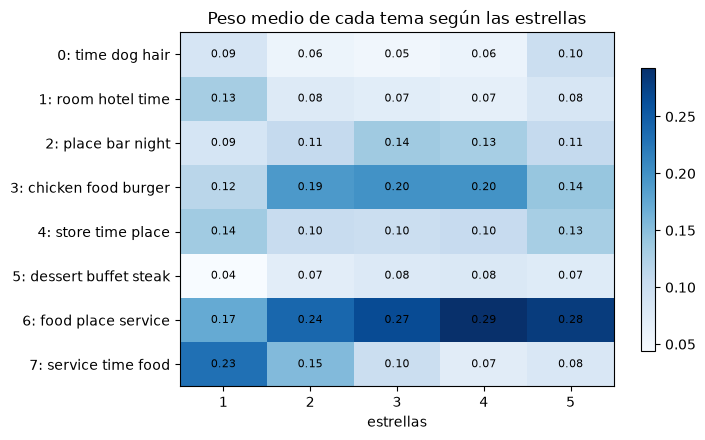

In [10]:
theta = np.zeros((len(corpus), lda.num_topics))
for i, bow in enumerate(corpus):
    for k, p in lda.get_document_topics(bow, minimum_probability=0):
        theta[i, k] = p

by_stars = pd.DataFrame(theta).groupby(reviews["stars"]).mean().T
by_stars.index = [f"{k}: {' '.join(topic_words[k][:3])}" for k in range(lda.num_topics)]

fig, ax = plt.subplots(figsize=(7, 0.45 * lda.num_topics + 1))
im = ax.imshow(by_stars.values, cmap="Blues", aspect="auto")
ax.set(xticks=range(5), xticklabels=by_stars.columns, yticks=range(len(by_stars)), yticklabels=by_stars.index,
       title="Peso medio de cada tema según las estrellas", xlabel="estrellas")
for (i, j), v in np.ndenumerate(by_stars.values):
    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.show()

La reseña de ejemplo (un hotel de Las Vegas) es un 55 % del tema de hoteles y un 40 % del tema 4: los temas de un documento no son exclusivos.

En todo el corpus, sin haber usado las estrellas para entrenar, el tema 7 (servicio y esperas) pesa 0,23 en las reseñas de 1 estrella y solo 0,07–0,08 en las de 4 y 5; el tema 6 (restaurantes en general) hace lo contrario (de 0,17 a 0,28–0,29), y la comida rápida (tema 3) se concentra en las reseñas intermedias. Los temas resumen el contenido y, de paso, generan variables útiles para un [clasificador](06-clasificacion-de-texto.ipynb).

### 3.5. WordNet: sentidos, jerarquía y etiquetas para los temas

Primero, lo básico: los sentidos de una palabra, la cadena de hiperónimos de un sentido y su ancestro común con otro.

In [11]:
for word in ["server", "burger", "fry", "order"]:
    senses = wn.synsets(word, pos=wn.NOUN)
    print(f"{word}: {len(senses)} sentidos como nombre; el primero ({senses[0].name()}): {senses[0].definition()}")

pizza, hamburger = wn.synset("pizza.n.01"), wn.synset("hamburger.n.01")
print("\nHiperónimos de pizza.n.01:", " → ".join(s.name().split(".")[0] for s in pizza.hypernym_paths()[0][::-1]))
print("Ancestro común de pizza.n.01 y hamburger.n.01:", pizza.lowest_common_hypernyms(hamburger))
print(f"Similitud pizza–hamburger: camino {pizza.path_similarity(hamburger):.2f} · "
      f"Wu-Palmer {pizza.wup_similarity(hamburger):.2f} · Leacock-Chodorow {pizza.lch_similarity(hamburger):.2f}")

def best_senses(a, b):
    # par de sentidos (como nombre) con la máxima similitud de Wu-Palmer
    pairs = [(sa.wup_similarity(sb) or 0, sa, sb) for sa in wn.synsets(a, pos=wn.NOUN) for sb in wn.synsets(b, pos=wn.NOUN)]
    return max(pairs, key=lambda p: p[0], default=(0, None, None))

first = wn.synsets("pizza", pos=wn.NOUN)[0].wup_similarity(wn.synsets("burger", pos=wn.NOUN)[0])
score, sa, sb = best_senses("pizza", "burger")
print(f"\npizza–burger con el primer sentido: {first:.2f} · con el mejor par ({sa.name()}, {sb.name()}): {score:.2f}")

server: 4 sentidos como nombre; el primero (waiter.n.01): a person whose occupation is to serve at table (as in a restaurant)
burger: 2 sentidos como nombre; el primero (burger.n.01): United States jurist appointed chief justice of the United States Supreme Court by Richard Nixon (1907-1995)
fry: 3 sentidos como nombre; el primero (fry.n.01): English painter and art critic (1866-1934)
order: 15 sentidos como nombre; el primero (order.n.01): (often plural) a command given by a superior (e.g., a military or law enforcement officer) that must be obeyed

Hiperónimos de pizza.n.01: pizza → dish → nutriment → food → substance → matter → physical_entity → entity
Ancestro común de pizza.n.01 y hamburger.n.01: [Synset('dish.n.02')]


Similitud pizza–hamburger: camino 0.20 · Wu-Palmer 0.78 · Leacock-Chodorow 2.03

pizza–burger con el primer sentido: 0.25 · con el mejor par (pizza.n.01, hamburger.n.01): 0.78


- *server* tiene como primer sentido el camarero, pero el primero de *burger* es Warren Burger, presidente del Tribunal Supremo de EE. UU.; el de *fry*, un pintor inglés, y el de *order*, una orden militar. El primer sentido es el más frecuente en los textos con los que se construyó WordNet, no en las reseñas.
- Con ese primer sentido, la similitud de Wu-Palmer entre *pizza* y *burger* es 0,25; con el mejor par de sentidos (*hamburger*), 0,78, porque las dos son platos (*dish*).
- Las tres medidas no están en la misma escala: para el mismo par, camino 0,20, Wu-Palmer 0,78 y Leacock-Chodorow 2,03.

In [12]:
# Palabras que están entre las 10 primeras de 3 o más temas: no ayudan a distinguirlos
counts = Counter(w for words in topic_words.values() for w in words)
generic = {w for w, c in counts.items() if c >= 3}
print("Palabras genéricas (en 3 o más temas):", sorted(generic))

def wordnet_label(words, min_similarity=0.7):
    # ancestro común más frecuente entre los pares de palabras parecidas (mejor par de sentidos)
    common = Counter()
    for a, b in itertools.combinations(words, 2):
        score, sa, sb = best_senses(a, b)
        if score >= min_similarity:
            common.update(h.name().split(".")[0] for h in sa.lowest_common_hypernyms(sb))
    return ", ".join(f"{h} ({c})" for h, c in common.most_common(3))

Palabras genéricas (en 3 o más temas): ['food', 'place', 'service', 'time']


Para cada par de palabras del tema buscamos el mejor par de sentidos y, si su similitud de Wu-Palmer llega a 0,7, contamos su ancestro común; por debajo, los ancestros son conceptos tan generales (*entity*, *object*, *abstraction*) que no sirven de etiqueta.

### 3.6. ConceptNet: relaciones de sentido común

Cargamos las relaciones y vemos las de *pizza*.

In [13]:
with contextlib.redirect_stderr(io.StringIO()):
    conceptnet_path = hf_hub_download("peandrew/conceptnet_en_nomalized", "data/train-00000-of-00001.parquet",
                                      repo_type="dataset", cache_dir="data")
conceptnet = pd.read_parquet(conceptnet_path)              # columnas: relación, concepto origen, concepto destino
print(f"Aristas: {len(conceptnet):,}")
print(conceptnet["rel"].value_counts().head(8).to_dict())

pizza_edges = conceptnet[conceptnet["arg1"] == "pizza"]
pizza_edges.groupby("rel")["arg2"].apply(lambda s: ", ".join(s.head(6)))

Aristas: 2,633,258
{'relatedto': 1928764, 'hascontext': 229601, 'isa': 227647, 'hassubevent': 66602, 'usedfor': 39457, 'causes': 30401, 'atlocation': 26983, 'capableof': 22328}


rel
atlocation                                  oven, plate, restaurant
causes                                                        drink
createdby                                               pizza_store
hasproperty                                  baked_in_oven, popular
isa               flatbread, disc_shaped_food_item, fast_food, f...
receivesaction                                  meant_to_cheap_food
relatedto                  baked, bread, cheese, crust, dish, fruit
Name: arg2, dtype: str

El volcado tiene 2,6 millones de relaciones en inglés, casi tres cuartas partes del tipo genérico `relatedto`. Las de *pizza* mezclan conocimiento útil (es *flatbread* y *fast_food*, está en un *oven* o un *restaurant*) con el ruido típico de las contribuciones colectivas (*fruit*, *meant_to_cheap_food*).

Para etiquetar un tema, buscamos los conceptos a los que apuntan más palabras del tema con `IsA` o `RelatedTo`. En los dos recursos quitamos antes las palabras genéricas, que estarían en todos los temas.

In [14]:
related = conceptnet[conceptnet["rel"].isin(["isa", "relatedto"])]

def conceptnet_label(words):
    # conceptos a los que apuntan más palabras del tema con IsA o RelatedTo
    targets = related[related["arg1"].isin(words) & ~related["arg2"].isin(words)]
    common = targets.drop_duplicates(["arg1", "arg2"])["arg2"].value_counts()
    return ", ".join(f"{c} ({n})" for c, n in common.head(3).items())

pd.DataFrame({
    "palabras (sin las genéricas)": [", ".join([w for w in words if w not in generic][:6]) for words in topic_words.values()],
    "WordNet: ancestros comunes": [wordnet_label([w for w in words if w not in generic]) for words in topic_words.values()],
    "ConceptNet: conceptos relacionados": [conceptnet_label([w for w in words if w not in generic]) for words in topic_words.values()],
}, index=[f"tema {k}" for k in topic_words])

,palabras (sin las genéricas),WordNet: ancestros comunes,ConceptNet: conceptos relacionados
tema 0,"dog, hair, year, nail, day, review","time_period (2), restraint (1), structure (1)","time (3), time_period (3), time_unit (3)"
tema 1,"room, hotel, day, hour, staff, bed","artifact (3), structure (1), opportunity (1)","four (5), people (5), unit (5)"
tema 2,"bar, night, drink, people, area, music","area (1), act (1), implement (1)","place (4), fun (4), like (4)"
tema 3,"chicken, burger, sauce, sandwich, fry, cheese","dish (2), meat (1), sandwich (1)","food (7), hamburger (3), meal (3)"
tema 4,"store, price, shop, location, customer, thing","shop (1), artifact (1), workplace (1)","object (4), business (4), buying (4)"
tema 5,"dessert, buffet, steak, cream, chocolate, ice","nutriment (5), food (3), dessert (1)","food (6), meal (5), drink (3)"
tema 6,"restaurant, pizza, menu, price, lunch, staff",nutriment (1),"food (4), meal (2), bill (2)"
tema 7,"minute, table, order, customer, server, manager","arrangement (1), food (1)","eating (3), food (3), like (3)"


- Las etiquetas automáticas funcionan con los temas de **comida** y con el de tiendas: WordNet da *dish* y *meat* para el tema 3, *nutriment* y *food* para el 5 y *shop* para el 4; ConceptNet, *food*, *hamburger* y *meal* para el 3, y *business* y *buying* para el 4.
- Con los temas de lugares y servicio fallan: entre *bar*, *night*, *drink* y *music* no hay ningún ancestro común útil en WordNet (son ramas distintas de la jerarquía), y ConceptNet devuelve conceptos vagos o ruidosos (*four*, *unit*, *like*).
- Ninguno de los dos recursos ve lo que une de verdad las palabras de esos temas en este corpus: que aparecen en el mismo tipo de negocio. Sirven para proponer etiquetas; la etiqueta final la pone una persona.

### 3.7. Similitud en WordNet frente a embeddings

Comparamos la similitud de Wu-Palmer (con el primer sentido de cada palabra y con el mejor par de sentidos) con el coseno entre los vectores GloVe de 100 dimensiones (los mismos del [notebook de embeddings](04-embeddings-de-palabras.ipynb), ya descargados en `data/`).

In [15]:
repo = "fse/glove-wiki-gigaword-100"
with contextlib.redirect_stderr(io.StringIO()):          # silencia las barras de descarga
    glove_path = hf_hub_download(repo, "glove-wiki-gigaword-100.model", cache_dir="data")
    hf_hub_download(repo, "glove-wiki-gigaword-100.model.vectors.npy", cache_dir="data")
glove = KeyedVectors.load(glove_path)

pairs = [("food", "pizza"), ("pizza", "burger"), ("coffee", "tea"), ("waiter", "waitress"),
         ("pizza", "oven"), ("good", "bad"), ("car", "pizza")]
pd.DataFrame([{
    "par": f"{a} – {b}",
    "WordNet, primer sentido": round(wn.synsets(a)[0].wup_similarity(wn.synsets(b)[0]), 2),
    "WordNet, mejor par": round(best_senses(a, b)[0], 2),
    "GloVe (coseno)": round(float(glove.similarity(a, b)), 2),
} for a, b in pairs]).set_index("par")

,"WordNet, primer sentido","WordNet, mejor par",GloVe (coseno)
par,,,
food – pizza,0.77,0.77,0.45
pizza – burger,0.25,0.78,0.70
coffee – tea,0.89,0.89,0.77
waiter – waitress,0.96,0.96,0.78
pizza – oven,0.20,0.20,0.49
good – bad,0.67,0.80,0.77
car – pizza,0.21,0.24,0.21


- *food* y *pizza*: 0,77 en WordNet (la pizza **es** comida) y 0,45 en GloVe: *food* es un término general que se usa en contextos mucho más variados que *pizza*.
- *pizza* y *burger*: con el primer sentido, WordNet da 0,25 (compara la pizza con un juez); con el mejor par, 0,78, cerca de GloVe (0,70).
- *pizza* y *oven*: lejos en WordNet (0,20: un plato y un electrodoméstico) y más cerca en GloVe (0,49), porque aparecen juntos. Es una relación **temática**, no de tipo.
- *good* y *bad*: 0,77 en GloVe, porque los antónimos comparten contextos, y 0,80 en WordNet con el mejor par, porque como nombres (el bien y el mal) son hermanos en la jerarquía. Ninguna de las dos medidas sirve para separar antónimos.

WordNet responde a «¿es un tipo de?» y los embeddings a «¿se usan en los mismos contextos?». Las cifras de una y otra no son comparables.

## 4. Parámetros importantes y errores comunes

| Parámetro | Qué controla | Valores típicos / consejo |
|---|---|---|
| `num_topics` ($K$) | Número de temas | Prueba varios (5–20) con la coherencia y lee los temas; elige el menor que separe lo que te interesa |
| `alpha`, `eta` | Concentración de temas por documento y de palabras por tema | `"auto"` los aprende; un $\alpha$ bajo da documentos con pocos temas |
| `passes`, `iterations` | Pasadas por el corpus e iteraciones por documento | 5–20 pasadas; si los temas cambian mucho entre ejecuciones, sube las dos |
| `random_state` | Inicialización | Fíjalo, pero compara con varias semillas |
| `filter_extremes(no_below, no_above)` | Vocabulario | Quita lo raro (< 10–20 documentos) y lo omnipresente (> 30–50 %) |
| Categorías gramaticales | Qué palabras entran | Solo nombres (o nombres y compuestos nominales) para temas de contenido |
| `coherence` (`CoherenceModel`) | Medida | `"c_v"` (necesita los textos, más lenta) o `"u_mass"` (solo el corpus, más rápida) |

**Errores comunes y lecciones aprendidas**

- **Incluir adjetivos de opinión.** En un análisis propio de reseñas de restaurantes de Yelp, el LDA con nombres y adjetivos daba temas con *good*, *great* y *food* entre las primeras palabras de casi todos: los adjetivos de valoración aparecen en cualquier reseña y no definen ningún tema. Aquí pasa lo mismo (demo abajo): con adjetivos, la coherencia baja y *good* o *great* se cuelan en varios temas. Si interesa la opinión sobre cada tema, se analiza aparte ([análisis de sentimientos](07-analisis-de-sentimientos.ipynb)).
- **Fiarse de una sola ejecución.** En ese análisis, la coherencia del mismo modelo apareció como 0,71 en el notebook y 0,686 en el informe: bastó con volver a ejecutarlo tras un cambio en el preprocesamiento. Con tres semillas (sección 3.2), la coherencia del mismo $K$ varía varias centésimas, tanto como la diferencia entre valores de $K$ vecinos: no elijas $K$ por una diferencia que está dentro del ruido.
- **Tomar el primer sentido de WordNet.** En ese análisis se comparó *food* con el primer sentido de *pizza* (`wn.synsets("pizza", pos=wn.NOUN)[0]`), que en ese caso sí es la pizza. Pero el primer sentido no tiene por qué ser el del dominio: el de *burger* es un juez del Tribunal Supremo de EE. UU., el de *fry* un pintor inglés y el de *order* una orden militar (sección 3.5). Con *burger* tomado así, la similitud con *pizza* cae de 0,78 a 0,25. Elige el sentido a mano para las palabras clave, o usa el mejor par de sentidos.
- **Comparar escalas que no son comparables.** En ese mismo análisis se comparó la similitud de Wu-Palmer entre *food* y *pizza* (0,77) con su coseno en un Word2Vec entrenado con las reseñas (0,13) como si fueran dos medidas de la misma «distancia». Miden cosas distintas (sección 3.7), y el coseno además depende del corpus, del preprocesamiento y de los hiperparámetros: con el Word2Vec del [notebook de embeddings](04-embeddings-de-palabras.ipynb) (otra muestra, sin lematizar ni quitar palabras vacías, ventana 5), el mismo par sale 0,61, y en GloVe, 0,45. No hay un valor que signifique «parecido» en general. Además, son **similitudes**, no distancias.
- **Leer los temas como categorías limpias.** Un tema es una distribución sobre todo el vocabulario; las palabras genéricas (*place*, *time*) aparecen arriba en varios. Para etiquetarlos, quítalas o usa una medida de relevancia que penalice las palabras frecuentes en todo el corpus (como la de pyLDAvis).

In [16]:
# Nombres y adjetivos frente a solo nombres (mismo K y semilla)
dictionary_na = Dictionary(nouns_adjs)
dictionary_na.filter_extremes(no_below=20, no_above=0.5)
corpus_na = [dictionary_na.doc2bow(doc) for doc in nouns_adjs]
lda_na = train_lda(corpus_na, dictionary_na, K, 42)
print(f"Coherencia C_V con K={K}: solo nombres {scores[K, 42]:.3f} · nombres y adjetivos {coherence(lda_na, nouns_adjs, dictionary_na):.3f}")

adjectives = {"good", "great", "nice", "best", "bad", "delicious", "friendly", "little", "new", "amazing"}
for k in range(K):
    words = [w for w, _ in lda_na.show_topic(k, topn=8)]
    print(f"tema {k}: {', '.join(f'[{w}]' if w in adjectives else w for w in words)}")

Coherencia C_V con K=8: solo nombres 0.607 · nombres y adjetivos 0.497
tema 0: burger, fry, coffee, [good], ice, place, cream, tea
tema 1: food, [good], chicken, restaurant, sauce, dish, salad, meal
tema 2: pizza, [good], sandwich, breakfast, cheese, place, egg, fresh
tema 3: time, service, customer, day, store, minute, place, [bad]
tema 4: food, [good], place, price, roll, buffet, service, well
tema 5: lot, shop, [great], parking, [little], day, beautiful, old
tema 6: place, [great], [good], food, bar, service, drink, time
tema 7: room, hotel, night, people, time, place, line, floor


Con nombres y adjetivos, la coherencia baja de 0,607 a 0,497, y *good* está entre las 8 primeras palabras de cinco de los ocho temas (y *great* en dos): el mismo resultado que en el análisis original. Los adjetivos de valoración se reparten por todos los temas y desplazan a los nombres que los distinguían.

## 5. Comparación con métodos relacionados

**Modelos de temas**

| Método | Idea | Ventajas | Inconvenientes | Cuándo usarlo |
|---|---|---|---|---|
| LDA | Modelo probabilístico: documentos como mezcla de temas | Interpretable; mezcla de temas por documento | Sensible al preprocesamiento y a $K$; inestable entre ejecuciones | Exploración de corpus medianos y grandes |
| NMF (sobre [TF-IDF](03-representacion-vectorial-tfidf.ipynb)) | Factoriza la matriz documento-término en dos matrices no negativas | Rápido; temas a menudo más nítidos con textos cortos | Sin modelo probabilístico | Alternativa rápida a LDA |
| LSA (`TruncatedSVD`) | Descomposición en valores singulares de TF-IDF | Muy rápido; útil para reducir dimensión | Componentes con pesos negativos, difíciles de leer como temas | Reducción de dimensión antes de otro modelo |
| [Agrupamiento](../04-machine-learning/05-kmeans-y-derivados.ipynb) de embeddings (p. ej. BERTopic) | Agrupar embeddings de documentos y describir cada grupo con TF-IDF | Capta sinónimos y contexto; bueno con textos cortos | Un solo tema por documento; necesita un modelo preentrenado | Textos cortos (tuits, títulos), cuando hay GPU |

**Recursos para la similitud entre palabras**

| Recurso | Qué mide | Ventajas | Inconvenientes |
|---|---|---|---|
| WordNet | Similitud taxonómica (jerarquía «es un tipo de») | Hecho a mano, preciso; distingue sentidos | Cobertura limitada (sin jerga, marcas, platos recientes); hay que elegir el sentido |
| ConceptNet | Relaciones de sentido común (es un, está en, sirve para, relacionado con) | Muchas relaciones y conceptos, incluidas las temáticas; multilingüe | Ruidoso; no distingue sentidos |
| [Embeddings](04-embeddings-de-palabras.ipynb) | Similitud distribucional (contextos parecidos) | Se aprenden de cualquier corpus; cubren la jerga del dominio | Mezclan sinónimos, antónimos y temas; un vector por palabra |

## 6. Referencias

### Fuentes

- Zhang, X., Zhao, J. y LeCun, Y. (2015). «Character-level convolutional networks for text classification». *Advances in Neural Information Processing Systems 28 (NIPS 2015)*, 649–657. Origen de Yelp Review Full, descargado de Hugging Face ([`Yelp/yelp_review_full`](https://huggingface.co/datasets/Yelp/yelp_review_full)) con [`datasets.load_dataset`](https://huggingface.co/docs/datasets/loading).
- gensim: [`models.ldamodel`](https://radimrehurek.com/gensim/models/ldamodel.html), [`models.coherencemodel`](https://radimrehurek.com/gensim/models/coherencemodel.html) y [`corpora.dictionary`](https://radimrehurek.com/gensim/corpora/dictionary.html).
- spaCy: [Linguistic Features](https://spacy.io/usage/linguistic-features) (etiquetado PoS y lematización) y [`Language.pipe`](https://spacy.io/api/language#pipe).
- WordNet: Princeton University (2010), [About WordNet](https://wordnet.princeton.edu/); consultado con el [WordNet HOWTO de NLTK](https://www.nltk.org/howto/wordnet.html).
- ConceptNet 5: Speer, R., Chin, J. y Havasi, C. (2017). «ConceptNet 5.5: An Open Multilingual Graph of General Knowledge». *Proceedings of the AAAI Conference on Artificial Intelligence*, 31(1), 4444–4451. [Web del proyecto](https://conceptnet.io/); relaciones en inglés descargadas de Hugging Face ([`peandrew/conceptnet_en_nomalized`](https://huggingface.co/datasets/peandrew/conceptnet_en_nomalized)).
- Vectores [GloVe](https://nlp.stanford.edu/projects/glove/) (`glove.6B.100d`), en formato de gensim desde [`fse/glove-wiki-gigaword-100`](https://huggingface.co/fse/glove-wiki-gigaword-100).

### Para saber más

- Blei, D. M., Ng, A. Y. y Jordan, M. I. (2003). «Latent Dirichlet Allocation». *Journal of Machine Learning Research*, 3, 993–1022. El artículo original de LDA: el modelo generativo, la inferencia variacional y la comparación con LSA y pLSI.
- Blei, D. M. (2012). «Probabilistic topic models». *Communications of the ACM*, 55(4), 77–84. Introducción breve y muy clara a los modelos de temas, sus supuestos y sus extensiones.